# 05e Loaded 05a MLP Retraining for Dataset 1

Simple experiment using the MLP model saved by notebook 05a.

- Dataset 1: keep the same temporal split structure as 05a and continue training from the loaded fitted 05a MLP.
- Dataset 2: use a random split and train a fresh model using the saved 05a MLP specs.

In [3]:
from pathlib import Path
import copy
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
from src.models.ml_train_and_store import load_model, top1_bank_cohort, top1_metrics

EMB_DIR = PROJECT_ROOT / 'src' / 'data' / 'embeddings'
MODEL_DIR = PROJECT_ROOT / 'src' / 'models' / 'train_saved' / '05_a'
OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'predictions' / '05e_dataset1_loaded_05a_mlp'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COL = 'log_systemic_risk_label'
RANDOM_STATE = 42
TARGET_DISTRIBUTION_BINS = 10
ROUND_DECIMALS = 3
METRIC_COLUMNS = [
    'train_rmse', 'validation_rmse',
    'train_mae', 'validation_mae',
    'train_top1_rmse', 'validation_top1_rmse',
    'train_top1_mae', 'validation_top1_mae',
]

pd.set_option('display.max_columns', 120)
print(PROJECT_ROOT)

C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis


## Inputs

In [4]:
P_LABELS = ['p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40']

dataset1_files = {
    'dataset1_baseline': 'graphsage_v1_32_srisk_dataset.parquet',
    **{f'dataset1_{p}': f'graphsage_v1_32_{p}_dataset.parquet' for p in P_LABELS},
}

dataset2_files = {
    'dataset2_baseline': 'graphsage_v1_32_dataset2_dataset.parquet',
    **{f'dataset2_{p}': f'graphsage_v1_32_dataset2_{p}_dataset.parquet' for p in P_LABELS},
}

MODEL_PATH = MODEL_DIR / 'MLP_(tuned).joblib'

if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

models = {
    'MLP (tuned)': load_model(MODEL_PATH)
}

print('Models:', list(models))
print('Dataset 1 files:', len(dataset1_files))
print('Dataset 2 files:', len(dataset2_files))

Models: ['MLP (tuned)']
Dataset 1 files: 9
Dataset 2 files: 9


## Helpers

In [5]:
def load_dataset(filename):
    df = pd.read_parquet(EMB_DIR / filename).copy()
    feature_cols = [c for c in df.columns if c.startswith('emb_')]
    df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
    return df, feature_cols


def temporal_split(df):
    keyed = df.copy()
    keyed['_key'] = keyed['year'] * 10 + keyed['quarter']

    train_df = keyed[keyed['_key'] <= 20214].drop(columns='_key')
    val_df = keyed[(keyed['_key'] > 20214) & (keyed['_key'] <= 20224)].drop(columns='_key')
    test_df = keyed[(keyed['_key'] > 20224) & (keyed['_key'] <= 20233)].drop(columns='_key')

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def make_stratify_bins(df, max_bins=TARGET_DISTRIBUTION_BINS):
    y = df[TARGET_COL]
    max_bins = min(max_bins, y.nunique())

    for n_bins in range(max_bins, 1, -1):
        try:
            bins = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            continue

        counts = pd.Series(bins).value_counts()
        if len(counts) > 1 and counts.min() >= 2:
            return bins

    return None


def random_split(df):
    stratify_bins = make_stratify_bins(df)
    train_val_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_bins,
    )

    val_stratify_bins = make_stratify_bins(train_val_df)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=0.15 / 0.85,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=val_stratify_bins,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
    }


def add_predictions(dataset_name, experiment, model_name, split_name, split_df, model, feature_cols):
    id_cols = [c for c in ['bank_id', 'year', 'quarter', 'period'] if c in split_df.columns]
    pred_df = split_df[id_cols + [TARGET_COL]].copy()
    pred_df['prediction'] = model.predict(split_df[feature_cols])
    pred_df['abs_error'] = (pred_df[TARGET_COL] - pred_df['prediction']).abs()
    pred_df.insert(0, 'split', split_name)
    pred_df.insert(0, 'model', model_name)
    pred_df.insert(0, 'experiment', experiment)
    pred_df.insert(0, 'dataset', dataset_name)
    return pred_df


def prepare_loaded_model_for_retraining(saved_model):
    model = copy.deepcopy(saved_model)
    warm_start_params = {
        key: True
        for key in model.get_params()
        if key == 'warm_start' or key.endswith('__warm_start')
    }
    if warm_start_params:
        model.set_params(**warm_start_params)
    return model


def fit_and_score(dataset_name, experiment, df, feature_cols, train_df, val_df, test_df, reuse_loaded_model, cohort=None):
    # Pass cohort=set() to skip top-1% scoring (used for dataset 2 where each bank has 1 row).
    if cohort is None:
        cohort = top1_bank_cohort(train_df, TARGET_COL)

    rows = []
    preds = []

    for model_name, saved_model in models.items():
        if reuse_loaded_model:
            # Deep copy keeps the fitted 05a weights, then fit continues from that state.
            model = prepare_loaded_model_for_retraining(saved_model)
        else:
            # Clone keeps the saved hyperparameters but starts with an unfitted model.
            model = clone(saved_model)
        model.fit(train_df[feature_cols], train_df[TARGET_COL])

        row = {'dataset': dataset_name, 'experiment': experiment, 'model': model_name}
        for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
            y_pred = model.predict(split_df[feature_cols])
            split_metrics = metrics(split_df[TARGET_COL], y_pred)
            split_top1_metrics = top1_metrics(split_df, y_pred, cohort, TARGET_COL)
            row[f'{split_name}_mae'] = split_metrics['mae']
            row[f'{split_name}_rmse'] = split_metrics['rmse']
            row[f'{split_name}_top1_mae'] = split_top1_metrics['mae']
            row[f'{split_name}_top1_rmse'] = split_top1_metrics['rmse']
            preds.append(add_predictions(dataset_name, experiment, model_name, split_name, split_df, model, feature_cols))

        rows.append(row)

    return rows, preds

def prepare_metric_table(df):
    df = df.copy()
    df = df.drop(columns=[col for col in df.columns if col.endswith('_r2') or col.startswith('test_')], errors='ignore')

    metric_cols = [col for col in df.columns if any(name in col for name in ['rmse', 'mae'])]
    df[metric_cols] = df[metric_cols].round(ROUND_DECIMALS)

    id_cols = ['dataset', 'experiment', 'model']
    ordered_cols = [col for col in [*id_cols, *METRIC_COLUMNS] if col in df.columns]
    other_cols = [col for col in df.columns if col not in ordered_cols]
    return df[ordered_cols + other_cols]


## Dataset 1 - temporal split, retrain loaded 05a MLP

In [6]:
all_rows = []
all_predictions = []

for dataset_name, filename in dataset1_files.items():
    df, feature_cols = load_dataset(filename)
    train_df, val_df, test_df = temporal_split(df)
    rows, preds = fit_and_score(
        dataset_name,
        'dataset1_temporal_retrain_loaded_05a_mlp',
        df,
        feature_cols,
        train_df,
        val_df,
        test_df,
        reuse_loaded_model=True,
    )
    all_rows.extend(rows)
    all_predictions.extend(preds)
    print(f'Done with {dataset_name}')

dataset1_results = prepare_metric_table(pd.DataFrame(all_rows))
display(dataset1_results.sort_values(['dataset', 'validation_rmse']))

Done with dataset1_baseline
Done with dataset1_p5
Done with dataset1_p10
Done with dataset1_p15
Done with dataset1_p20
Done with dataset1_p25
Done with dataset1_p30
Done with dataset1_p35
Done with dataset1_p40


,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset1_baseline,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.150,0.207,0.044,0.055,1.297,1.799,1.050,1.593
2,dataset1_p10,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.193,0.250,0.058,0.069,1.760,2.233,1.530,2.059
3,dataset1_p15,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.205,0.259,0.054,0.065,1.843,2.307,1.619,2.137
4,dataset1_p20,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.211,0.267,0.064,0.076,1.913,2.367,1.693,2.200
5,dataset1_p25,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.220,0.277,0.059,0.070,2.006,2.449,1.789,2.286
6,dataset1_p30,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.238,0.286,0.064,0.076,2.092,2.513,1.876,2.354
7,dataset1_p35,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.240,0.296,0.067,0.078,2.181,2.597,1.968,2.447
8,dataset1_p40,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.188,0.228,0.035,0.042,1.571,1.910,1.296,1.721
1,dataset1_p5,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.146,0.139,0.026,0.031,0.838,1.037,0.652,0.895


## Dataset 2 - random split, train with saved 05a MLP specs

In [7]:
dataset2_train_rows = []

for dataset_name, filename in dataset2_files.items():
    df, feature_cols = load_dataset(filename)
    train_df, val_df, test_df = random_split(df)
    rows, preds = fit_and_score(
        dataset_name,
        'dataset2_random_train_05a_mlp_specs',
        df,
        feature_cols,
        train_df,
        val_df,
        test_df,
        reuse_loaded_model=False,
        cohort=set(),  # skip top-1% on dataset 2 (1 row per bank, no cross-split overlap)
    )
    dataset2_train_rows.extend(rows)
    all_predictions.extend(preds)

dataset2_train_results = prepare_metric_table(pd.DataFrame(dataset2_train_rows))
display(dataset2_train_results.sort_values(['dataset', 'validation_rmse']))

,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset2_baseline,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.181,0.208,0.066,0.075,NaN,NaN,NaN,NaN
2,dataset2_p10,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.243,0.369,0.106,0.121,NaN,NaN,NaN,NaN
3,dataset2_p15,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.214,0.255,0.089,0.107,NaN,NaN,NaN,NaN
4,dataset2_p20,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.241,0.263,0.107,0.113,NaN,NaN,NaN,NaN
5,dataset2_p25,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.185,0.189,0.097,0.110,NaN,NaN,NaN,NaN
6,dataset2_p30,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.293,0.318,0.159,0.161,NaN,NaN,NaN,NaN
7,dataset2_p35,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.170,0.246,0.072,0.097,NaN,NaN,NaN,NaN
8,dataset2_p40,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.267,0.489,0.134,0.171,NaN,NaN,NaN,NaN
1,dataset2_p5,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.219,0.473,0.131,0.169,NaN,NaN,NaN,NaN


## Save outputs

In [8]:
results = pd.concat(
    [dataset1_results, dataset2_train_results],
    ignore_index=True,
    sort=False,
)
results = prepare_metric_table(results)
predictions = pd.concat(all_predictions, ignore_index=True)

results_path = OUT_DIR / 'metrics.csv'
predictions_path = OUT_DIR / 'predictions.csv'

results.to_csv(results_path, index=False)
predictions.to_csv(predictions_path, index=False)

print(f'Saved metrics: {results_path}')
print(f'Saved predictions: {predictions_path}')

display(results.sort_values(['dataset', 'experiment']))

Saved metrics: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\05e_dataset1_loaded_05a_mlp\metrics.csv
Saved predictions: C:\Users\ruben\Desktop\Universidade\Nova IMS\Tese\Thesis\src\data\predictions\05e_dataset1_loaded_05a_mlp\predictions.csv


,dataset,experiment,model,train_rmse,validation_rmse,train_mae,validation_mae,train_top1_rmse,validation_top1_rmse,train_top1_mae,validation_top1_mae
0,dataset1_baseline,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.150,0.207,0.044,0.055,1.297,1.799,1.050,1.593
2,dataset1_p10,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.193,0.250,0.058,0.069,1.760,2.233,1.530,2.059
3,dataset1_p15,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.205,0.259,0.054,0.065,1.843,2.307,1.619,2.137
4,dataset1_p20,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.211,0.267,0.064,0.076,1.913,2.367,1.693,2.200
5,dataset1_p25,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.220,0.277,0.059,0.070,2.006,2.449,1.789,2.286
6,dataset1_p30,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.238,0.286,0.064,0.076,2.092,2.513,1.876,2.354
7,dataset1_p35,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.240,0.296,0.067,0.078,2.181,2.597,1.968,2.447
8,dataset1_p40,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.188,0.228,0.035,0.042,1.571,1.910,1.296,1.721
1,dataset1_p5,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.146,0.139,0.026,0.031,0.838,1.037,0.652,0.895
9,dataset2_baseline,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.181,0.208,0.066,0.075,NaN,NaN,NaN,NaN


## P-value comparison plots

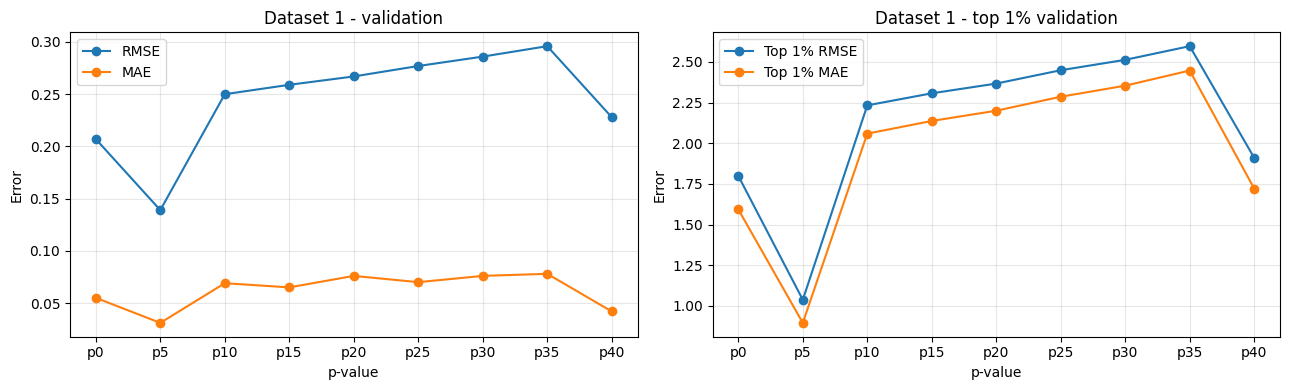

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.207,0.055,1.799,1.593
8,p5,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.139,0.031,1.037,0.895
1,p10,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.250,0.069,2.233,2.059
2,p15,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.259,0.065,2.307,2.137
3,p20,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.267,0.076,2.367,2.200
4,p25,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.277,0.070,2.449,2.286
5,p30,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.286,0.076,2.513,2.354
6,p35,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.296,0.078,2.597,2.447
7,p40,dataset1_temporal_retrain_loaded_05a_mlp,MLP (tuned),0.228,0.042,1.910,1.721


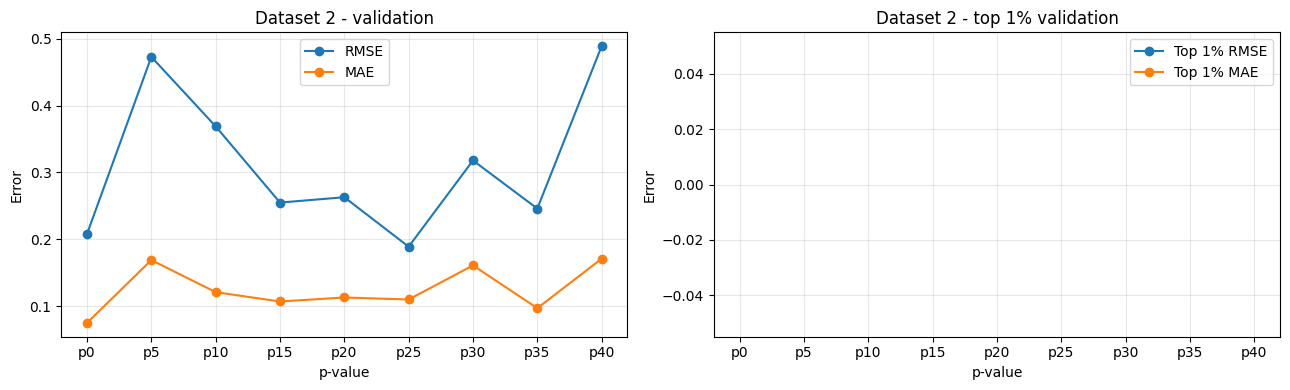

,p_value,experiment,model,validation_rmse,validation_mae,validation_top1_rmse,validation_top1_mae
0,p0,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.208,0.075,NaN,NaN
8,p5,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.473,0.169,NaN,NaN
1,p10,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.369,0.121,NaN,NaN
2,p15,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.255,0.107,NaN,NaN
3,p20,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.263,0.113,NaN,NaN
4,p25,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.189,0.110,NaN,NaN
5,p30,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.318,0.161,NaN,NaN
6,p35,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.246,0.097,NaN,NaN
7,p40,dataset2_random_train_05a_mlp_specs,MLP (tuned),0.489,0.171,NaN,NaN


In [9]:
def prepare_p_plot_data(results_df, dataset_prefix):
    baseline_name = f'{dataset_prefix}_baseline'
    is_baseline = results_df['dataset'].eq(baseline_name)
    is_p_value = results_df['dataset'].str.startswith(f'{dataset_prefix}_p')
    plot_df = results_df[is_baseline | is_p_value].copy()

    plot_df['p_value'] = plot_df['dataset'].str.extract(r'_(p\d+)$')[0]
    plot_df.loc[plot_df['dataset'].eq(baseline_name), 'p_value'] = 'p0'
    plot_df['p_num'] = plot_df['p_value'].str.extract(r'p(\d+)').astype(int)

    # Keep the best saved-model result for each p-value by test RMSE.
    best = (
        plot_df.sort_values(['dataset', 'validation_rmse', 'validation_mae'])
        .groupby('dataset', as_index=False)
        .first()
        .sort_values('p_num')
    )
    return best


def plot_p_value_comparison(results_df, dataset_prefix, title):
    best = prepare_p_plot_data(results_df, dataset_prefix)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

    axes[0].plot(best['p_value'], best['validation_rmse'], marker='o', label='RMSE')
    axes[0].plot(best['p_value'], best['validation_mae'], marker='o', label='MAE')
    axes[0].set_title(f'{title} - validation')
    axes[0].set_xlabel('p-value')
    axes[0].set_ylabel('Error')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(best['p_value'], best['validation_top1_rmse'], marker='o', label='Top 1% RMSE')
    axes[1].plot(best['p_value'], best['validation_top1_mae'], marker='o', label='Top 1% MAE')
    axes[1].set_title(f'{title} - top 1% validation')
    axes[1].set_xlabel('p-value')
    axes[1].set_ylabel('Error')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    plt.show()

    display_cols = [
        'p_value', 'experiment', 'model',
        'validation_rmse', 'validation_mae', 'validation_top1_rmse', 'validation_top1_mae',
    ]
    display(best[display_cols])


plot_p_value_comparison(results, 'dataset1', 'Dataset 1')
plot_p_value_comparison(results, 'dataset2', 'Dataset 2')